import Dataset

In [ ]:
from google.colab import drive
import os

# 1. Sambung ke Drive
drive.mount('/content/drive')

# 2. Ekstrak data zip ke memori lokal Colab biar ngebut
if not os.path.exists('/content/dataset_lokal/tomato'):
    print("Mengekstrak dataset...")
    !cp /content/drive/MyDrive/tomato.zip /content/
    !unzip -q /content/tomato.zip -d /content/dataset_lokal/
    print("Ekstrak selesai!")
else:
    print("Dataset sudah siap di memori lokal!")

# 3. Atur Jalur Folder
base_dir = '/content/dataset_lokal/tomato'
train_dir = os.path.join(base_dir, 'train')
val_dir = os.path.join(base_dir, 'val')

print("Siap! Lanjut ke Cell 2.")

Mounted at /content/drive
Mengekstrak dataset...
Ekstrak selesai!
Siap! Lanjut ke Cell 2.


Model EfficientNet

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers

# 1. Muat Data
img_size = (224, 224)
batch_size = 32

train_data = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir, image_size=img_size, batch_size=batch_size
)
val_data = tf.keras.preprocessing.image_dataset_from_directory(
    val_dir, image_size=img_size, batch_size=batch_size
)
class_names = train_data.class_names

# 2. Augmentasi Gambar (Biar model kenal daun miring/terbalik)
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
])

# 3. Panggil EfficientNet-B0 (Tanpa kepala aslinya)
base_model = tf.keras.applications.EfficientNetB0(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False # Kunci dulu untuk pemanasan

# 4. Rangkai Model Lengkap
inputs = tf.keras.Input(shape=(224, 224, 3))
x = data_augmentation(inputs)
x = base_model(x, training=False) # Normalisasi otomatis terjadi di sini!
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.2)(x) # Mencegah over-fitting
outputs = layers.Dense(len(class_names), activation='softmax')(x)

model_efficient = tf.keras.Model(inputs, outputs)

# 5. Compile Model
model_efficient.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_efficient.summary()

Found 10000 files belonging to 10 classes.
Found 1000 files belonging to 10 classes.
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        12,810 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,062,381 (15.50 MB)

 Trainable params: 12,810 (50.04 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

Training

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Rem otomatis kalau akurasi tidak naik dalam 5 putaran
early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    restore_best_weights=True
)

# Simpan otomatis ke Drive kamu
checkpoint = ModelCheckpoint(
    '/content/drive/MyDrive/skripsi/model_efficientnet_awal.keras',
    monitor='val_accuracy',
    save_best_only=True
)

print("Memulai Training EfficientNet-B0...")
history = model_efficient.fit(
    train_data,
    validation_data=val_data,
    epochs=15,
    callbacks=[early_stop, checkpoint]
)

Memulai Training EfficientNet-B0...
Epoch 1/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 51s 113ms/step - accuracy: 0.6627 - loss: 1.1539 - val_accuracy: 0.7810 - val_loss: 0.7834
Epoch 2/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 29s 88ms/step - accuracy: 0.8168 - loss: 0.6416 - val_accuracy: 0.8200 - val_loss: 0.6094
Epoch 3/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 28s 90ms/step - accuracy: 0.8482 - loss: 0.5208 - val_accuracy: 0.8270 - val_loss: 0.5408
Epoch 4/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 28s 90ms/step - accuracy: 0.8620 - loss: 0.4581 - val_accuracy: 0.8390 - val_loss: 0.4915
Epoch 5/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 32s 101ms/step - accuracy: 0.8700 - loss: 0.4199 - val_accuracy: 0.8430 - val_loss: 0.4681
Epoch 6/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 27s 87ms/step - accuracy: 0.8790 - loss: 0.3866 - val_accuracy: 0.8420 - val_loss: 0.4339
Epoch 7/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 28s 90ms/step - accuracy: 0.8814 - loss: 0.3710 - val_accuracy: 0.8810 - val_loss: 0.3935
Epoch 8/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 27s 87ms/ste

Report

In [ ]:
from sklearn.metrics import classification_report
import numpy as np

print("Sedang memproses evaluasi model...")
y_true = []
y_pred = []

for images, labels in val_data:
    preds = model_efficient.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

print("\n--- HASIL EVALUASI EFFICIENTNET-B0 ---")
print(classification_report(y_true, y_pred, target_names=class_names))

Sedang memproses evaluasi model...
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111m

Save Model

In [ ]:
import tensorflow as tf

print("Memulai proses penyimpanan model...")

# 1. Simpan ulang dalam format .keras (untuk jaga-jaga / backup)
path_keras = '/content/drive/MyDrive/skripsi/model_efficientnet_final.keras'
model_efficient.save(path_keras)
print(f"1. Model berhasil disimpan sebagai .keras di: {path_keras}")

# 2. Proses Konversi ke TensorFlow Lite (.tflite)
print("Sedang mengonversi model ke format TFLite (ini butuh waktu beberapa detik)...")
converter = tf.lite.TFLiteConverter.from_keras_model(model_efficient)

# (Opsional tapi disarankan) Optimasi ukuran file agar aplikasi mobile tidak berat
converter.optimizations = [tf.lite.Optimize.DEFAULT]

tflite_model = converter.convert()

# 3. Simpan file .tflite ke Google Drive
path_tflite = '/content/drive/MyDrive/skripsi/model_efficientnet_final.tflite'
with open(path_tflite, 'wb') as f:
    f.write(tflite_model)

print(f"2. Model berhasil dikonversi dan disimpan sebagai .tflite di: {path_tflite}")
print("SELESAI! Model siap dimasukkan ke aplikasi mobile.")

Memulai proses penyimpanan model...
1. Model berhasil disimpan sebagai .keras di: /content/drive/MyDrive/skripsi/model_efficientnet_final.keras
Sedang mengonversi model ke format TFLite (ini butuh waktu beberapa detik)...
Saved artifact at '/tmp/tmp62stni8k'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_238')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  137934288246864: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  137934288248784: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  137934347633488: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137934327776656: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137934327791440: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137934327791248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137934327789904: TensorSpec(shape=(), dtype=tf.re

Plot Grafik

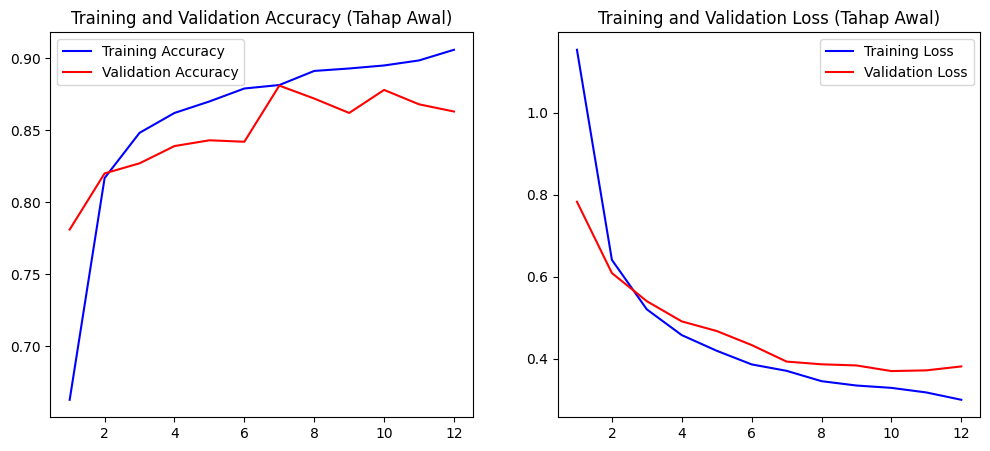

In [ ]:
import matplotlib.pyplot as plt

# Ambil data dari riwayat training tahap awal (sebelum fine-tune)
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(acc) + 1)

# Buat kanvas grafik
plt.figure(figsize=(12, 5))

# Grafik Akurasi
plt.subplot(1, 2, 1)
plt.plot(epochs, acc, 'b', label='Training Accuracy')
plt.plot(epochs, val_acc, 'r', label='Validation Accuracy')
plt.title('Training and Validation Accuracy (Tahap Awal)')
plt.legend()

# Grafik Loss
plt.subplot(1, 2, 2)
plt.plot(epochs, loss, 'b', label='Training Loss')
plt.plot(epochs, val_loss, 'r', label='Validation Loss')
plt.title('Training and Validation Loss (Tahap Awal)')
plt.legend()

plt.show()

Test Model

Silakan pilih dan upload 1 gambar daun tomat dari laptop kamu:


Saving Early-blight-2.jpg to Early-blight-2.jpg

[INFO] Berhasil memuat gambar: Early-blight-2.jpg

[INFO] Memuat model .keras...
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
[INFO] Memuat model .tflite (Interpreter)...


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


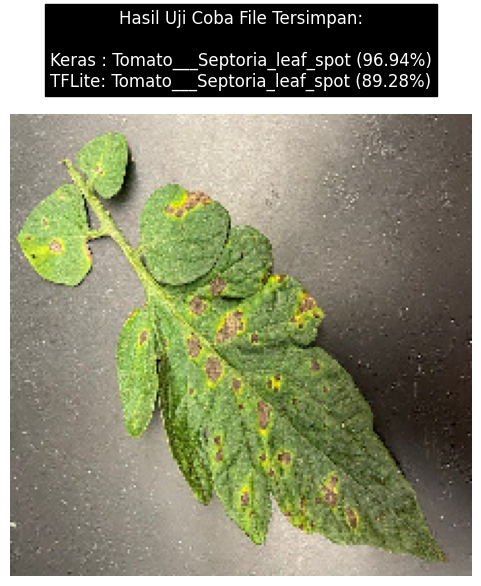


✅ STATUS: SUKSES! Model .tflite bekerja sama baiknya dengan model .keras.


In [ ]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
from google.colab import files

print("Silakan pilih dan upload 1 gambar daun tomat dari laptop kamu:")
uploaded = files.upload()

# Mengambil nama file
nama_file = ""
for fn in uploaded.keys():
    nama_file = str(fn)
    print(f"\n[INFO] Berhasil memuat gambar: {nama_file}")
    break

# Preprocessing Gambar (dipakai bersama oleh kedua model)
img = image.load_img(nama_file, target_size=(224, 224))
img_array = image.img_to_array(img)
img_array_tf = tf.expand_dims(img_array, 0)


# --- 1. TES MENGGUNAKAN MODEL .KERAS ---
print("\n[INFO] Memuat model .keras...")
model_keras = tf.keras.models.load_model('/content/drive/MyDrive/skripsi/model_efficientnet_final.keras')

prediksi_keras = model_keras.predict(img_array_tf)
akurasi_keras = np.max(prediksi_keras) * 100
label_keras = class_names[np.argmax(prediksi_keras)]


# --- 2. TES MENGGUNAKAN MODEL .TFLITE (Simulasi Android) ---
print("[INFO] Memuat model .tflite (Interpreter)...")
interpreter = tf.lite.Interpreter(model_path='/content/drive/MyDrive/skripsi/model_efficientnet_final.tflite')
interpreter.allocate_tensors()

input_details  = interpreter.get_input_details()   # list of dicts
output_details = interpreter.get_output_details()  # list of dicts

# ✅ PERBAIKAN: tambahkan [0] sebelum ['index']
interpreter.set_tensor(input_details[0]['index'], img_array_tf)
interpreter.invoke()

prediksi_tflite = interpreter.get_tensor(output_details[0]['index'])
akurasi_tflite  = np.max(prediksi_tflite) * 100
label_tflite    = class_names[np.argmax(prediksi_tflite)]


# --- 3. TAMPILKAN HASIL BERSAMAAN ---
plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.axis('off')
plt.title(
    f"Hasil Uji Coba File Tersimpan:\n\n"
    f"Keras : {label_keras} ({akurasi_keras:.2f}%)\n"
    f"TFLite: {label_tflite} ({akurasi_tflite:.2f}%)",
    fontsize=12, pad=20, backgroundcolor='black', color='white'
)
plt.show()

if label_keras == label_tflite:
    print("\n✅ STATUS: SUKSES! Model .tflite bekerja sama baiknya dengan model .keras.")
else:
    print("\n⚠️ STATUS: ADA PERBEDAAN PREDIKSI. (Sangat jarang terjadi)")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor']]
Received: inputs=['Tensor(shape=(1, 224, 224, 3))']
  warnings.warn(msg)


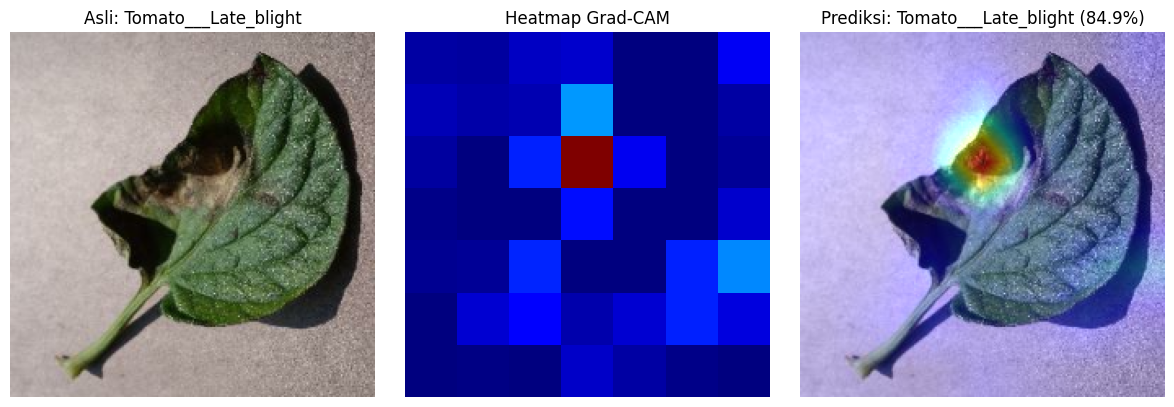

In [ ]:
import cv2
import matplotlib.cm as cm
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# Name of the last convolutional layer for Grad-CAM (corrected for EfficientNetB0)
LAST_CONV_LAYER = 'top_activation'

def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    # Ensure the model's base (EfficientNetB0) is targetable by Grad-CAM
    # The base_model is the second layer in model_efficient (after Input and Data Augmentation)
    base_model_for_gradcam = model.get_layer('efficientnetb0')

    grad_model = tf.keras.models.Model(
        [base_model_for_gradcam.inputs], [base_model_for_gradcam.get_layer(last_conv_layer_name).output, base_model_for_gradcam.output]
    )

    with tf.GradientTape() as tape:
        # Ensure the input img_array is treated as float32 for gradient tape
        # Preprocessing (normalization) is handled by the model's base_model internally for EfficientNetB0
        # Pass img_array as a list to match the model's input signature, resolving the UserWarning.
        last_conv_layer_output, _ = grad_model([img_array])

        # Pass the processed output of base_model through the custom head of model_efficient
        x = model.get_layer('global_average_pooling2d')(last_conv_layer_output)
        x = model.get_layer('dropout')(x)
        preds = model.get_layer('dense')(x)

        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    grads = tape.gradient(class_channel, last_conv_layer_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    # Normalize heatmap to range 0-1
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

# Ambil satu gambar contoh dari Validation Set yang sudah di-load di Sel 7
# Iterate over val_data to get one batch
for images, labels in val_data.take(1):
    val_images_batch = images.numpy()
    val_labels_batch = labels.numpy()
    break # Take only the first batch

# Use the first image from the batch
# The images from image_dataset_from_directory are typically float32 in 0-255 range
img_array_for_gradcam = tf.expand_dims(val_images_batch[0], 0) # This is the raw image (0-255)
actual_label_index = val_labels_batch[0]
actual_class = class_names[actual_label_index]

# Prediksi menggunakan model_efficient
preds = model_efficient.predict(img_array_for_gradcam)
pred_label_index = np.argmax(preds[0])
pred_class = class_names[pred_label_index]
confidence = preds[0][pred_label_index] * 100

# Buat Heatmap
# Pass the raw image (0-255) to make_gradcam_heatmap as model_efficient expects it
heatmap = make_gradcam_heatmap(img_array_for_gradcam, model_efficient, LAST_CONV_LAYER)

# Visualisasi Gabungan
# img_array_for_gradcam[0] is already float32 in 0-255 range. Convert to uint8 directly.
img_original = img_array_for_gradcam[0].numpy().astype("uint8")

heatmap_resized = cv2.resize(heatmap, (img_original.shape[1], img_original.shape[0]))
heatmap_resized = np.uint8(255 * heatmap_resized)
heatmap_colored = cv2.applyColorMap(heatmap_resized, cv2.COLORMAP_JET)
# Convert heatmap_colored from BGR (cv2 default) to RGB for matplotlib display
heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)

superimposed_img = heatmap_colored * 0.4 + img_original
superimposed_img = np.clip(superimposed_img, 0, 255).astype('uint8')

# Plot Hasilnya
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.imshow(img_original)
plt.title(f"Asli: {actual_class}")
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(heatmap, cmap='jet')
plt.title("Heatmap Grad-CAM")
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(superimposed_img)
plt.title(f"Prediksi: {pred_class} ({confidence:.1f}%)")
plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, balanced_accuracy_score
import numpy as np

print("Sedang memproses prediksi pada data validasi (mohon tunggu sebentar)...")
y_true = []
y_pred = []

# Mengambil tebakan model dan jawaban asli dari seluruh data validasi
for images, labels in val_data:
    preds = model_efficient.predict(images, verbose=0) # verbose=0 agar layar tidak penuh teks
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

# Menghitung ketiga metrik
akurasi = accuracy_score(y_true, y_pred)
macro_f1 = f1_score(y_true, y_pred, average='macro')
balanced_acc = balanced_accuracy_score(y_true, y_pred)

# Menampilkan hasil dengan rapi untuk di-copy ke naskah jurnal
print("\n=== RINGKASAN METRIK EVALUASI MODEL ===")
print(f"1. Accuracy          : {akurasi:.4f}  ({akurasi * 100:.2f}%)")
print(f"2. Macro F1-Score    : {macro_f1:.4f}  ({macro_f1 * 100:.2f}%)")
print(f"3. Balanced Accuracy : {balanced_acc:.4f}  ({balanced_acc * 100:.2f}%)")
print("=======================================")

Sedang memproses prediksi pada data validasi (mohon tunggu sebentar)...

=== RINGKASAN METRIK EVALUASI MODEL ===
1. Accuracy          : 0.8810  (88.10%)
2. Macro F1-Score    : 0.8814  (88.14%)
3. Balanced Accuracy : 0.8810  (88.10%)
